# **Quantum Computing**
## 1\. The Theory: Qubits and the Bloch Sphere 

### What is a Qubit's State?

In classical computing, a bit is either a **0** or a **1**. In quantum computing, a **qubit**  can be **$|0\rangle$**  or **$|1\rangle$** , any combination of the two.

  * **$|0\rangle$** is often thought of as the initial or "ground" state.
  * **$|1\rangle$** is the "excited" state.

### What is the Bloch Sphere?

The **Bloch Sphere** is the standard way to geometrically represent the state of a single qubit.

  1. It's a sphere with a radius of **1**.
  2. Any point on the surface of this sphere represents a valid **qubit state**.
  3 The **Z-axis** (Vertical axis) is the most important for visualization:
      * The **North Pole** represents the state **$|0\rangle$**.
      * The **South Pole** represents the state **$|1\rangle$**.
    <img src="bloch 1.png" width="500" alt="bloch 1.png">

<p align="center">
  <img src="N:\qiskitproject _1\18_DayQiskit\Images\bloch 1.png" alt="bloch 1.png" style="width:30%; height:auto;">
</p>

When we visualize a state, we are simply drawing an arrow (a vector) from the center of the sphere to the point on the surface that represents the qubit's current state.

-----

## 2\. The Hands-On Code: Visualizing $|0\rangle$ and $|1\rangle$

We'll use **Qiskit**, the most popular quantum computing framework, for this.

### **Step 1: Setup and Imports**

This imports the necessary tools: `QuantumCircuit` to build the circuits and `Statevector` and `plot_bloch_multivector` for visualization.

In [1]:
import qiskit

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

### **Step 2: Visualizing $|0\rangle$ (The North Pole)**

By default, any qubit you create in Qiskit  starts in the **$|0\rangle$ state**. We don't need to apply any gates.


--- State |0⟩ (North Pole) ---


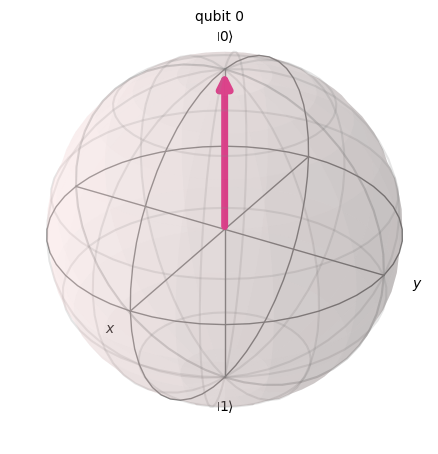

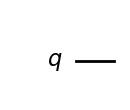

In [3]:
# Create a Quantum Circuit with 1 qubit
qc_zero = QuantumCircuit(1)

# Get the Statevector (the mathematical description of the state)
state_zero = Statevector.from_instruction(qc_zero)

print("--- State |0⟩ (North Pole) ---")

# Plot the state on the Bloch Sphere
display(plot_bloch_multivector(state_zero))
display(qc_zero.draw('mpl')) # Visualize the circuit (which is empty)

### **Step 3: Visualizing $|1\rangle$ (The South Pole)**

To move the qubit from the starting $|0\rangle$ state to the $|1\rangle$ state, we use the **X-gate** (also known as the quantum NOT gate or flip gate).


--- State |1⟩ (South Pole) ---


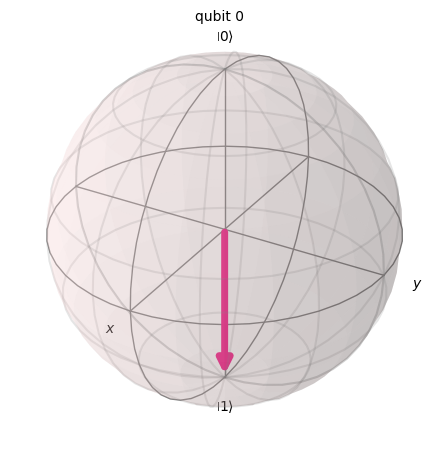

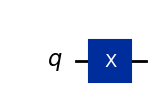

In [4]:
# Create a new Quantum Circuit
qc_one = QuantumCircuit(1)

# Apply the X-gate to flip the state
# X-gate flips the state from |0> to |1> (or vice versa)
qc_one.x(0) # Apply X-gate to qubit 0

# Get the new Statevector
state_one = Statevector.from_instruction(qc_one)

print("\n--- State |1⟩ (South Pole) ---")
# Plot the state on the Bloch Sphere
display(plot_bloch_multivector(state_one))
display(qc_one.draw('mpl')) # Visualize the circuit (now shows an X-gate)

**Observation:**

  * In the first plot, the arrow points straight up, indicating **$|0\rangle$**.
  * In the second plot, the X-gate flipped the arrow straight down, indicating **$|1\rangle$**.



 # **Hadamard (H) gate**
 That superposition state—$\frac{|0\rangle+|1\rangle}{\sqrt{2}}$—is the key to quantum speedup, and the **Hadamard (H) gate** is the simplest way to achieve it.

## Theory: The Power of the Hadamard Gate

The **Hadamard gate ($\mathbf{H}$)** is arguably the single most important gate in quantum computing because it instantly creates the **uniform superposition** required to explore many possibilities simultaneously.

1.  **The Starting Point:** Your qubit begins in the definite state:
    $$|\psi\rangle = |0\rangle$$

2.  **The H-Gate Action (The Rotation):** The H-gate acts like a specific kind of $90^\circ$ rotation that takes the Z-axis (where $|0\rangle$ is) and maps it to the X-axis (the equator). This means the qubit is now perfectly balanced between the $|0\rangle$ and $|1\rangle$ poles.

3.  **The Final State:** The resulting state vector is:
    $$|\psi\rangle = \frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle$$

### Intuition: The Quantum Coin Flip 

  * The coefficients ($\frac{1}{\sqrt{2}}$ for both $|0\rangle$ and $|1\rangle$) are called **amplitudes**.
  * The probability of measuring a state is the square of its amplitude.
  * Probability of measuring $|0\rangle$: $|\frac{1}{\sqrt{2}}|^2 = \frac{1}{2}$ (or 50%)
  * Probability of measuring $|1\rangle$: $|\frac{1}{\sqrt{2}}|^2 = \frac{1}{2}$ (or 50%)

The H-gate creates a perfectly **fair quantum coin flip**. Until you measure it, the qubit is simultaneously both heads and tails.

-----

## Code: Creating and Visualizing Superposition

Here is the Qiskit code to implement the H-gate and visualize its effect on the Bloch sphere, confirming the rotation to the equator.

### Step 1: Imports

In [23]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np # Used for potential later math, but good to include

### Step 2: Build the Circuit and Apply H-gate

We start with $|0\rangle$ (the default state) and apply the H-gate to qubit index 0.

--- Circuit Visualization (H-gate) ---


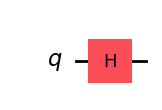

In [24]:
# 1. Create a 1-qubit circuit
qc_superposition = QuantumCircuit(1)

# 2. Apply the Hadamard gate to qubit 0
qc_superposition.h(0)

print("--- Circuit Visualization (H-gate) ---")
display(qc_superposition.draw('mpl'))

### Step 3: Visualize the Result

We extract the state vector and plot it on the Bloch sphere.


--- Bloch Sphere Visualization ---


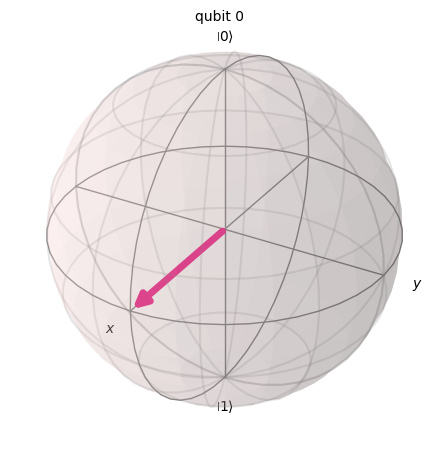

State Vector Amplitudes (Real part): [0.7071 0.7071]


In [25]:
# Calculate the final state vector
state_superposition = Statevector.from_instruction(qc_superposition)

print("\n--- Bloch Sphere Visualization ---")
# This should show the vector pointing along the positive X-axis (the equator)
display(plot_bloch_multivector(state_superposition))

# Check the exact state vector values
print(f"State Vector Amplitudes (Real part): {np.round(state_superposition.data.real, 4)}")
# Output should be: [0.7071 0.7071] (which is 1/sqrt(2) for |0> and 1/sqrt(2) for |1>)

# **Single-Qubit Pauli Gates**


##  Building the Pauli-X Gate in Code

The goal is to visually confirm the **$|0\rangle \to |1\rangle$** flip and the $180^\circ$ rotation around the X-axis.

### 1\. Setup and Circuit Creation

We'll start the qubit in the default $|0\rangle$ state (North Pole).


--- Initial State |0> (North Pole) ---


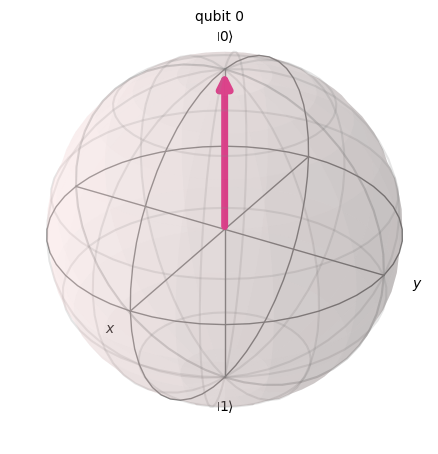

In [26]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np
# 1. Start with a 1-qubit circuit (initial state is |0>)
qc_x_gate = QuantumCircuit(1)

# Visualize the starting state |0> for comparison
state_initial = Statevector.from_instruction(qc_x_gate)
print("--- Initial State |0> (North Pole) ---")
display(plot_bloch_multivector(state_initial))

### 2\. Applying the X-Gate

We use the `.x(0)` method to apply the Pauli-X gate to qubit index 0.


--- Circuit Visualization (X-Gate Applied) ---


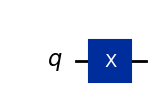

In [27]:
# 2. Apply the Pauli-X gate (Quantum NOT)
qc_x_gate.x(0) 

print("\n--- Circuit Visualization (X-Gate Applied) ---")
display(qc_x_gate.draw('mpl'))

### 3\. Visualizing the Resulting Flip

We calculate the new state vector and plot it. This should clearly show the vector moving from the North Pole ($|0\rangle$) to the South Pole ($|1\rangle$).


--- Final State |1> (South Pole) ---


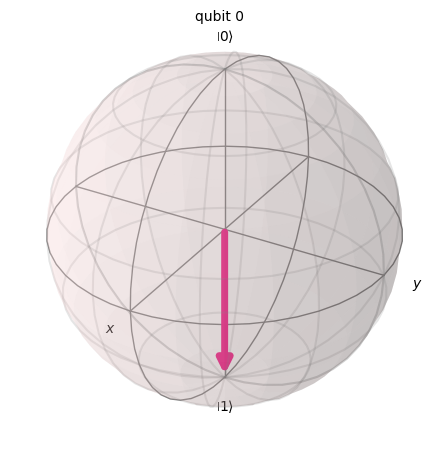

Final State Amplitudes: [0.+0.j 1.+0.j]


In [28]:
# 3. Get the final state vector (should be |1>)
state_final = Statevector.from_instruction(qc_x_gate)

print("\n--- Final State |1> (South Pole) ---")
display(plot_bloch_multivector(state_final))

# Check the amplitudes: [|0> amplitude, |1> amplitude]
print(f"Final State Amplitudes: {np.round(state_final.data, 4)}")
# Output: [0.+0.j 1.+0.j], confirming the state is now 1 * |1>

Figure(621.941x451.5)


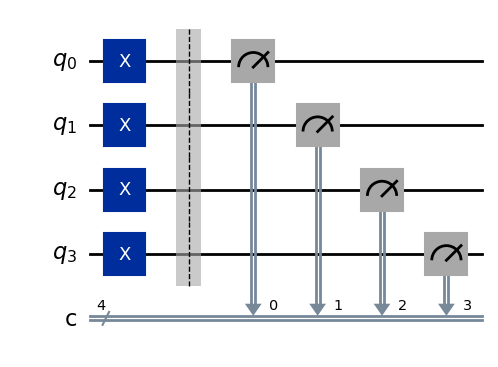

In [29]:
qc_gate = QuantumCircuit(4,4)
qc_gate.x(0)  # Apply X-gate to qubit 0
qc_gate.x(1)  # Apply X-gate to qubit 1
qc_gate.x(2)  # Apply X-gate to qubit 2
qc_gate.x(3)  # Apply X-gate to qubit 3
qc_gate.barrier()  # Add a barrier for visual separation
qc_gate.measure([0,1,2,3], [0,1,2,3])  # Measure all qubits into corresponding classical bits
print(qc_gate.draw('mpl'))  # Visualize the circuit
qc_gate.draw('mpl', filename='x_gate_circuit.png')  # Save the circuit diagram as a PNG file


## Pauli-Y Gate ($\mathbf{Y}$): The Hybrid Rotator 

The Pauli-Y gate is the third and final Pauli operator. It's often thought of as a combination of the X-gate  and the Z-gate, as it performs both actions simultaneously.

### Theory and Intuition

1.  **Bloch Sphere Effect:** The Y-gate performs a $\pi$ (180-degree) rotation around the **Y-axis** of the Bloch sphere.

2.  **Action on Basis States:**

      * $|0\rangle \xrightarrow{Y} i|1\rangle$
      * $|1\rangle \xrightarrow{Y} -i|0\rangle$

3.  **The Resulting Flip and Phase:** When applied to the starting state $|0\rangle$, it flips the bit to $|1\rangle$ (like the X-gate), but it also introduces an **imaginary phase ($i$)**.

      * On the Bloch sphere, this rotation takes the vector from the **North Pole** ($|0\rangle$) and lands it on the **negative Y-axis** (representing $i|1\rangle$). This distinct position is what sets it apart from the X-gate (which lands on the South Pole, $|1\rangle$).

4.  **Matrix Representation:**
    $$Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$$

-----

##  Building the Pauli-Y Gate in Code

We'll apply the Y-gate to the starting state $|0\rangle$ and visualize its unique landing position on the Bloch sphere.

### 1\. Circuit Creation and Application

--- Circuit Visualization (Y-Gate Applied) ---


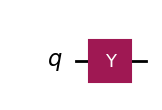

In [30]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np

# 1. Start with a 1-qubit circuit (initial state is |0>)
qc_y_gate = QuantumCircuit(1)

# 2. Apply the Pauli-Y gate
qc_y_gate.y(0) 

print("--- Circuit Visualization (Y-Gate Applied) ---")
display(qc_y_gate.draw('mpl'))

### 2\. Visualizing the Rotation to the Negative Y-axis


--- Final State (Negative Y-axis) ---


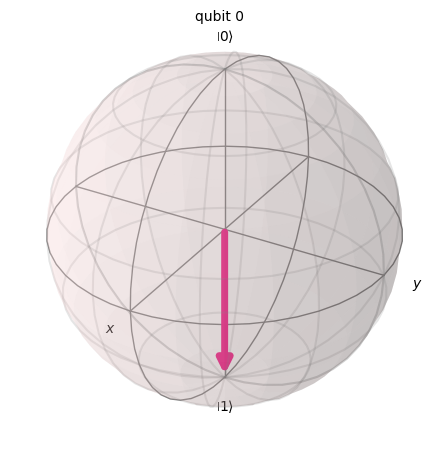

Final State Amplitudes: [0.+0.j 0.+1.j]


In [31]:
# 3. Get the final state vector (should be i|1>)
state_final = Statevector.from_instruction(qc_y_gate)

print("\n--- Final State (Negative Y-axis) ---")
# The vector should point directly towards the negative Y-axis.
display(plot_bloch_multivector(state_final))

# Check the amplitudes: Notice the imaginary component in the |1> amplitude
print(f"Final State Amplitudes: {state_final.data}")
# Output: [0.+0.j, 0.-1.j], confirming the state is now i * |1>

Figure(705.552x451.5)


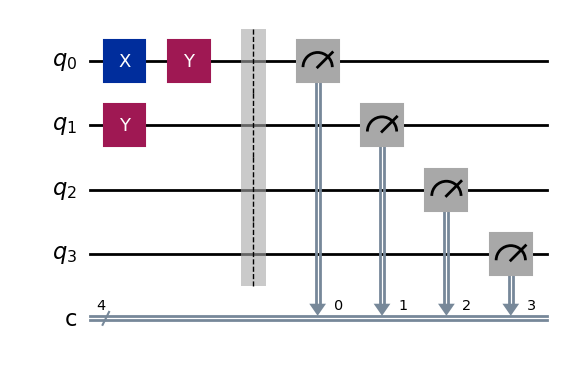

In [32]:
qc_gate = QuantumCircuit(4,4)
qc_gate.x(0)  # Apply X-gate to qubit 0
qc_gate.y(1)  # Apply Y-gate to qubit 1
qc_gate.y(0) # Apply Y-gate to qubit 0
qc_gate.barrier()  # Add a barrier for visual separation
qc_gate.measure([0,1,2,3], [0,1,2,3])  # Measure all qubits into corresponding classical bits
print(qc_gate.draw('mpl'))  # Visualize the circuit
qc_gate.draw('mpl', filename='y_gate_circuit.png')  # Save the circuit diagram as a PNG file

Conclusion: The Y-gate completes the Pauli set, demonstrating how a quantum gate can simultaneously change the qubit's classical value and its phase, a necessary capability for complex quantum calculations.

## Pauli-Z Gate ($\mathbf{Z}$): The Phase Shifter 
The Pauli-Z gate is crucial for quantum interference because it manipulates the **relative phase** between the $|0\rangle$ and $|1\rangle$ states. Unlike the Pauli-X gate, it doesn't flip the classical bit value.

### Theory and Intuition

1.  **Action on Basis States:**

      * **$|0\rangle$ remains $|0\rangle$:** The phase of the $|0\rangle$ state is unchanged.
      * **$|1\rangle$ changes to $-|1\rangle$:** The $|1\rangle$ state picks up a **negative sign** (a phase of $\pi$).

2.  **Matrix Representation:**
    $$Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

3.  **Bloch Sphere Effect:** The Z-gate performs a $\pi$ (180-degree) rotation around the **Z-axis** of the Bloch sphere.

4.  **The Key Insight (Phase Shift):**

      * If the qubit is in a definite state ($|0\rangle$ or $|1\rangle$), the Z-gate's effect isn't visually obvious on the Bloch sphere, as a rotation around the Z-axis doesn't move the North or South Pole.
      * The Z-gate only becomes significant when the qubit is in **superposition**, like the state created by the Hadamard gate: $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$.
      * Applying $Z$ to this state gives: $Z|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$.
      * This shift in the relative phase between the $|0\rangle$ and $|1\rangle$ components is what allows for **quantum interference**, which is the core trick behind most quantum algorithms\!

-----

## Building the Pauli-Z Gate in Code

We'll use the superposition state created by the H-gate to visually demonstrate the Z-gate's rotation.

### 1\. Starting in Superposition (Positive X-axis)

We first apply the H-gate to get the state on the positive X-axis (equator).

--- State after H-gate (Positive X-axis) ---


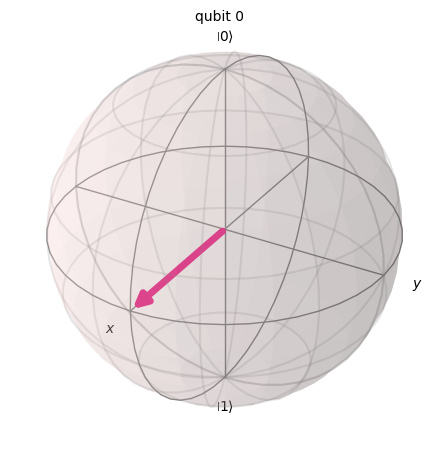

In [33]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np

# 1. Start with H-gate to create superposition
qc_z_gate = QuantumCircuit(1)
qc_z_gate.h(0) 

state_initial = Statevector.from_instruction(qc_z_gate)
print("--- State after H-gate (Positive X-axis) ---")
display(plot_bloch_multivector(state_initial))

### 2\. Applying the Z-Gate

Now we apply the Z-gate. This should rotate the vector $180^\circ$ around the Z-axis, moving it from the positive X-axis to the **negative X-axis**.


--- Circuit Visualization (H followed by Z) ---


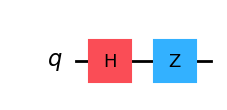


--- Final State (Negative X-axis) ---


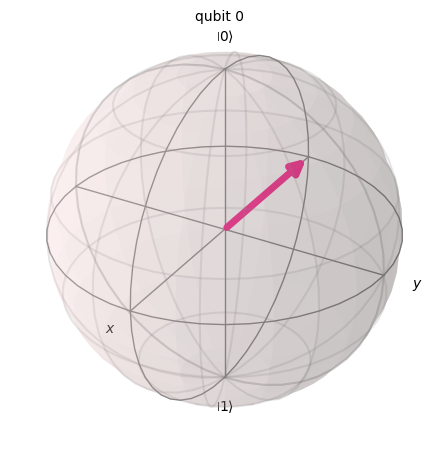

Final State Amplitudes: [ 0.7071+0.j -0.7071+0.j]


In [34]:
# 2. Apply the Pauli-Z gate
qc_z_gate.z(0) 

print("\n--- Circuit Visualization (H followed by Z) ---")
display(qc_z_gate.draw('mpl'))

# 3. Get the final state vector
state_final = Statevector.from_instruction(qc_z_gate)

print("\n--- Final State (Negative X-axis) ---")
# The vector should now point along the negative X-axis
display(plot_bloch_multivector(state_final))

# Check the amplitudes: The |1> component now has a negative coefficient
print(f"Final State Amplitudes: {np.round(state_final.data, 4)}")
# Output: [ 0.7071 -0.7071], representing 1/sqrt(2) * (|0> - |1>)

**Conclusion:** The visualization confirms that the Z-gate performs a rotation that changes the **relative phase** of the qubit state, a critical concept for Week 3's algorithms\!


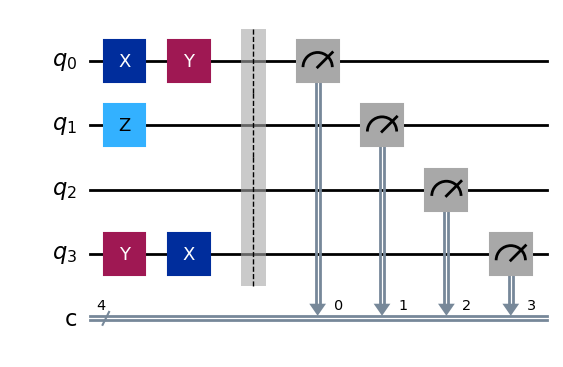

In [35]:
qc_gate = QuantumCircuit(4,4)
qc_gate.x(0)  # Apply X-gate to qubit 0l     
qc_gate.z(1)  # Apply Z-gate to qubit 1
qc_gate.y(0)  # Apply Y-gate to qubit 0
qc_gate.y(3)
qc_gate.x(3)   
qc_gate.barrier()  # Add a barrier for visual separation
qc_gate.measure([0,1,2,3], [0,1,2,3])  # Measure all qubits into corresponding classical bits
qc_gate.draw('mpl', filename='combined_gates_circuit.png')  # Save the circuit diagram as a PNG file


## Arbitrary Rotation Gate: $R_X(\theta)$

The $R_X(\theta)$ gate performs a rotation of **any arbitrary angle $\theta$ (theta)** around the **X-axis** of the Bloch sphere. This gate is the generalized form of the Pauli-X gate, where $X = R_X(\pi)$.

### Theory and Matrix Representation

1.  **Bloch Sphere Effect:** Rotates the qubit by an angle $\theta$ around the X-axis. Starting from the North Pole ($|0\rangle$), an $R_X(\theta)$ gate moves the state vector along a circular path defined by the X-axis.
2.  **Use Case:** This gate is critical for **Variational Quantum Algorithms (VQAs)**, where the angles ($\theta$) are parameters that a classical optimizer tunes to find a solution.

**Matrix Representation:**
The mathematical definition for an $R_X(\theta)$ gate is:
$$R_X(\theta) = \begin{pmatrix} \cos(\theta/2) & -i \sin(\theta/2) \\ -i \sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$
*Note the $\theta/2$ factor, which is standard in quantum mechanics and ensures the full $\theta$ rotation on the Bloch sphere.*

-----

###  Code: Visualizing an $R_X(\pi/2)$ Rotation

Let's apply a $90^\circ$ rotation ($\theta = \pi/2$) around the X-axis to the starting state $|0\rangle$.

--- Circuit Visualization (RX(π/2) Applied) ---


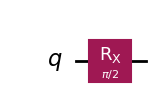


--- State after RX(1.57 rad) Rotation ---


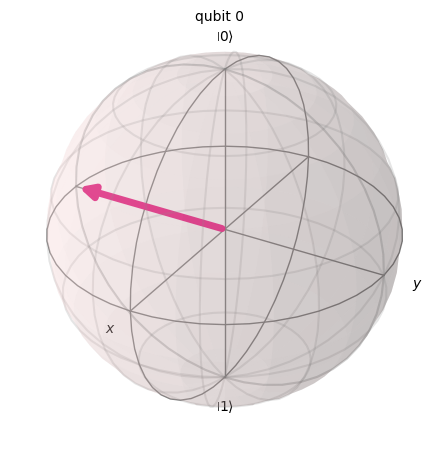

In [36]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np

# 1. Create a 1-qubit circuit
qc_rx = QuantumCircuit(1)

# Set the desired rotation angle to 90 degrees (pi/2 radians)
angle_rx = np.pi / 2 

# 2. Apply the RX gate with the angle
qc_rx.rx(angle_rx, 0) 

print("--- Circuit Visualization (RX(π/2) Applied) ---")
display(qc_rx.draw('mpl'))

# 3. Visualize the result on the Bloch Sphere
state_final = Statevector.from_instruction(qc_rx)

print(f"\n--- State after RX({angle_rx:.2f} rad) Rotation ---")
# The vector should move 90 degrees away from |0> along the rotation path
display(plot_bloch_multivector(state_final))

# Expected Outcome: The state vector moves towards the negative Z-Y plane.

**Observation:** When you run this, the vector should move $90^\circ$ away from $|0\rangle$, resulting in a superposition state with equal real and imaginary components.

That's an excellent question\! You've hit a common road bump when moving from single-qubit to multi-qubit circuits: **the standard `plot_bloch_multivector` function cannot visualize the state of a large, complex multi-qubit system like your 4-qubit circuit.**

The Bloch sphere is mathematically designed to represent the state of **only one qubit** at a time. Once you have two or more qubits, the full state space is 4D, 8D, 16D, and so on, which can't be mapped onto a 3D sphere.

However, you *can* visualize the **individual, final state of each qubit** on its own Bloch sphere. Since your qubits are **not entangled** yet (you haven't used CNOT or controlled gates), their final states are independent.

## Code for Multi-Qubit Visualization

To use the `plot_bloch_multivector` function, we must stop the simulation *before* the measurement and use the **state vector** of the entire system.

### Step 1: Modify the Circuit 

To get the state vector, we must define a new circuit that **excludes the measurement step**, as measurement collapses the state.


--- Circuit for Visualization ---


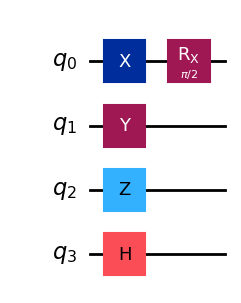

In [38]:

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import pi

# Define the full circuit (4 qubits)
qc_vis = QuantumCircuit(4)
qc_vis.x(0) 
qc_vis.y(1) 
qc_vis.z(2) 
qc_vis.h(3) 
qc_vis.rx(pi/2, 0)

print("--- Circuit for Visualization ---")
display(qc_vis.draw('mpl'))

### Step 2: Calculate the Final State Vector

We calculate the final state vector for the 4-qubit system.

In [39]:
# Calculate the 4-qubit Statevector
state_4q = Statevector.from_instruction(qc_vis)

### Step 3: Visualize Individual Qubit States

The `plot_bloch_multivector` function is actually smart enough to process the multi-qubit state vector (`state_4q`) and plot the state of **each individual qubit** onto its own Bloch sphere.

```python
print("\n--- Final State Visualization (Individual Qubits) ---")
# Qiskit automatically computes the reduced state for each qubit and plots it.
display(plot_bloch_multivector(state_4q))
```

-----

# Qubit State Predictions on the Bloch Sphere

Since the qubits are independent, we can track each gate sequentially to predict their individual final positions on the Bloch sphere.

| Qubit | Applied Gates | Prediction Logic | Final Position on Bloch Sphere |
| :---: | :--- | :--- | :--- |
| **Qubit 0** | $X \to R_X(\pi/2)$ | $X$ flips $\|0\rangle$ to $\|1\rangle$ (South Pole). $R_X(\pi/2)$ then rotates the state by $90^\circ$ around the X-axis. | **Negative Z/Y plane** |
| **Qubit 1** | $Y$ | $Y$ maps |$\|0\rangle$ to $i\|1\rangle$. | **Negative Y-axis** |
| **Qubit 2** | $Z$ | $Z$ acts on $\|0\rangle$ leaving its phase unchanged at the North Pole. | **North Pole ($\|0\rangle$)** |
| **Qubit 3** | $H$ | Hadamard creates an equal superposition, rotating $\|0\rangle$ to $\|+\rangle$. | **Positive X-axis** |


Running the code will show four separate Bloch spheres confirming these positions\! This technique works perfectly for **product states** (non-entangled states). Once you introduce entanglement (in Week 2), the visualization becomes more complex, but the principle of calculating the system's state first remains the same.

--- Circuit for Visualization ---


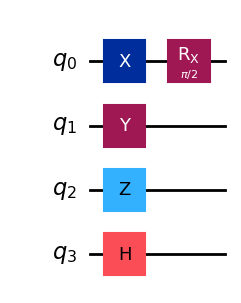

In [41]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import pi

# Define the full circuit (4 qubits)
qc_vis = QuantumCircuit(4)
qc_vis.x(0) 
qc_vis.y(1) 
qc_vis.z(2) 
qc_vis.h(3) 
qc_vis.rx(pi/2, 0) 

print("--- Circuit for Visualization ---")
display(qc_vis.draw('mpl'))

In [42]:
# Calculate the 4-qubit Statevector
state_4q = Statevector.from_instruction(qc_vis)


--- Final State Visualization (Individual Qubits) ---


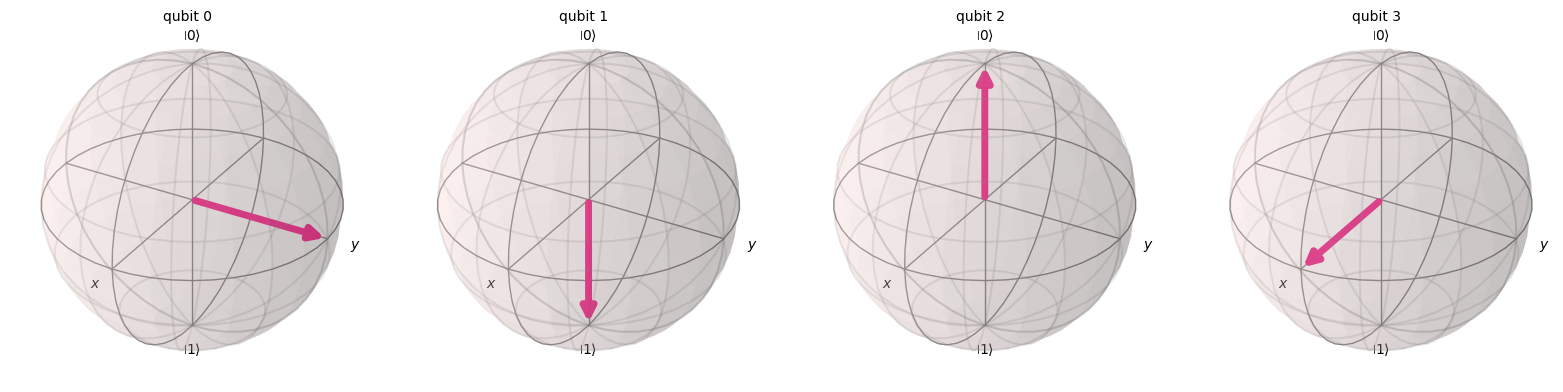

In [43]:
print("\n--- Final State Visualization (Individual Qubits) ---")
# Qiskit automatically computes the reduced state for each qubit and plots it.
display(plot_bloch_multivector(state_4q))

Let's complete the set of arbitrary rotation gates by focusing on the **$R_Y$ Gate**. This gate is arguably the most common rotation gate used in modern quantum machine learning and optimization algorithms.

-----

## Arbitrary Rotation Gate: $R_Y(\theta)$

The **$R_Y(\theta)$** gate performs a rotation of any arbitrary angle $\theta$ (theta) around the **Y-axis** of the Bloch sphere. It is the generalized version of the Pauli-Y gate, where $Y = R_Y(\pi)$.

### Theory and Intuition

1.  **Bloch Sphere Effect:** $R_Y(\theta)$ rotates the qubit by an angle $\theta$ around the Y-axis. When applied to the starting state $|0\rangle$, it moves the vector from the North Pole down toward the equator or the South Pole. This rotation is crucial because it directly changes the **measurement probabilities** of the qubit.
2.  **Probability Control:** As discussed previously, if you apply $R_Y(\theta)$ to $|0\rangle$, the measurement probabilities are directly controlled by the angle $\theta$:
      * $P(|0\rangle) = \cos^2(\theta/2)$
      * $P(|1\rangle) = \sin^2(\theta/2)$
        This ability to precisely dial in a desired probability distribution makes $R_Y(\theta)$ vital for preparing specific quantum states.
3.  **Use Case:** The $R_Y$ gate is the backbone of **Variational Quantum Eigensolver (VQE)** and other **Quantum Machine Learning (QML)** models, where parameters (like $\theta$) are optimized by a classical computer to find the best solution.

**Matrix Representation:**
$$R_Y(\theta) = \begin{pmatrix} \cos(\theta/2) & -\sin(\theta/2) \\ \sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$

-----

### Code: Visualizing an $R_Y(\pi/3)$ Rotation

Let's apply a $60^\circ$ rotation ($\theta = \pi/3$) around the Y-axis to the starting state $|0\rangle$.



--- Circuit Visualization (RY(π/3) Applied) ---


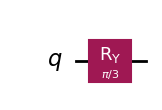


--- State after RY(1.05 rad) Rotation ---


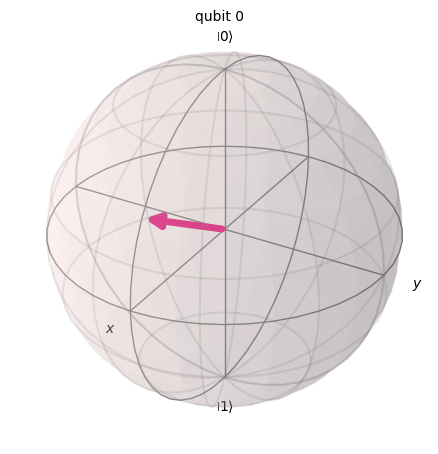

In [44]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np
from math import pi

# 1. Create a 1-qubit circuit
qc_ry = QuantumCircuit(1)

# Set the desired rotation angle to 60 degrees (pi/3 radians)
angle_ry = pi / 3 

# 2. Apply the RY gate with the angle
qc_ry.ry(angle_ry, 0) 

print("--- Circuit Visualization (RY(π/3) Applied) ---")
display(qc_ry.draw('mpl'))

# 3. Visualize the result on the Bloch Sphere
state_final = Statevector.from_instruction(qc_ry)

print(f"\n--- State after RY({angle_ry:.2f} rad) Rotation ---")
# The vector should move 60 degrees away from |0> along the Z-Y plane.
display(plot_bloch_multivector(state_final))

**Predicted Outcome Check:**
Using the probability formulas for $\theta = \pi/3$:

  * $P(|0\rangle) = \cos^2((\pi/3)/2) = \cos^2(\pi/6) = (\sqrt{3}/2)^2 = 3/4 = 75\%$
  * $P(|1\rangle) = \sin^2(\pi/6) = (1/2)^2 = 1/4 = 25\%$

The visualization confirms the vector moves $60^\circ$ down from the North Pole, putting it into a state where it has a $75\%$ chance of being measured as $|0\rangle$.

## Arbitrary Rotation Gate: $R_Z(\theta)$

### Theory and Intuition

1.  **Bloch Sphere Effect:** The $R_Z(\theta)$ gate rotates the qubit by an angle $\theta$ around the **Z-axis**.
      * Since the $|0\rangle$ and $|1\rangle$ states lie on the Z-axis, applying $R_Z(\theta)$ to either of these states does **not change its position** on the sphere.
      * The $R_Z$ gate is only visible and effective when the qubit is in **superposition** (i.e., on the equator or elsewhere away from the Z-axis). It changes the qubit's **phase** without affecting the measurement probabilities.
2.  **Phase Control:** Unlike $R_X$ and $R_Y$ (which mix the amplitudes of $|0\rangle$ and $|1\rangle$), the $R_Z$ gate is a pure phase gate. This means it only introduces a **relative phase shift** between the $|0\rangle$ and $|1\rangle$ components, which is crucial for creating **constructive and destructive interference** in algorithms.
3.  **Matrix Representation:**
    $$R_Z(\theta) = \begin{pmatrix} e^{-i\theta/2} & 0 \\ 0 & e^{i\theta/2} \end{pmatrix}$$

-----

###  Code: Visualizing an $R_Z(\pi/2)$ Rotation

To see the $R_Z$ gate in action, we must first put the qubit in **superposition** using the Hadamard ($H$) gate.

--- Circuit Visualization (H followed by RZ(π/2)) ---


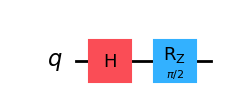


--- State after RZ(1.57 rad) Rotation ---


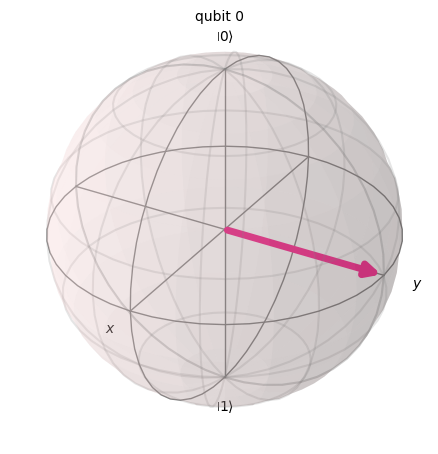

In [45]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np
from math import pi

# 1. Create a 1-qubit circuit
qc_rz = QuantumCircuit(1)

# FIRST: Put the qubit in superposition (Positive X-axis)
qc_rz.h(0) 

# Set the desired rotation angle to 90 degrees (pi/2 radians)
angle_rz = pi / 2 

# 2. Apply the RZ gate with the angle
qc_rz.rz(angle_rz, 0) 

print("--- Circuit Visualization (H followed by RZ(π/2)) ---")
display(qc_rz.draw('mpl'))

# 3. Visualize the result on the Bloch Sphere
state_final = Statevector.from_instruction(qc_rz)

print(f"\n--- State after RZ({angle_rz:.2f} rad) Rotation ---")
# The vector should move 90 degrees around the Z-axis, landing on the Positive Y-axis.
display(plot_bloch_multivector(state_final))

**Predicted Outcome:**

1.  **After H-gate:** The vector points to the **Positive X-axis** (equator).
2.  **After $R_Z(\pi/2)$:** The vector rotates $90^\circ$ around the Z-axis (the pole the vector is spinning around), moving from the Positive X-axis to the **Positive Y-axis** (still on the equator).